In [ ]:
## CCDC5180"China resistant" — worst MDR,4 genes
## CCDC5079 — same hospital, opposite resistance profile
## KZN1435"South Africa MDR" — 4 genes, worst outbreak region
## F11"South Africa mystery" — pncA unexplained
## RGTB327"India mystery" — pncA unexplained, local relevance
## KZN4207"South Africa XDR" — worst resistance level, our pipeline can't fully capture it — shows limitation [MUTATIONS IN GENES OTHER THAN THE CHOSEN ONES]
## CDC1551"American control" — drug sensitive, zero mutations, proves our pipeline works [PERFECT STRAIN AS IT HAS 0 MUTATIONS DETECTED]

In [ ]:
%%bash
apt-get install -y bwa samtools bcftools wget > /dev/null 2>&1
echo "All tools installed successfully"

All tools installed successfully


In [ ]:
%%bash
mkdir -p /content/tb_project/reference
mkdir -p /content/tb_project/strains
mkdir -p /content/tb_project/aligned
mkdir -p /content/tb_project/vcf
mkdir -p /content/tb_project/results

wget -q "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000962.3&rettype=fasta&ret mode=text" \
  -O /content/tb_project/reference/H37Rv.fasta

echo "Reference genome downloaded"
wc -l /content/tb_project/reference/H37Rv.fasta

Reference genome downloaded
0 /content/tb_project/reference/H37Rv.fasta


In [ ]:
%%bash
# Remove corrupted file
rm -f /content/tb_project/reference/H37Rv.fasta

# Re-download with a longer timeout and verify
wget --timeout=120 --tries=3 \
  "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000962.3&rettype=fasta&retmode=text" \
  -O /content/tb_project/reference/H37Rv.fasta

# Verify it downloaded correctly
echo "File size:"
ls -lh /content/tb_project/reference/H37Rv.fasta

echo "Line count:"
wc -l /content/tb_project/reference/H37Rv.fasta

echo "First line (should show >NC_000962.3):"
head -1 /content/tb_project/reference/H37Rv.fasta

File size:
-rw-r--r-- 1 root root 4.3M Apr  9 03:31 /content/tb_project/reference/H37Rv.fasta
Line count:
63024 /content/tb_project/reference/H37Rv.fasta
First line (should show >NC_000962.3):
>NC_000962.3 Mycobacterium tuberculosis H37Rv, complete genome


--2026-04-09 03:31:49--  https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000962.3&rettype=fasta&retmode=text
Resolving eutils.ncbi.nlm.nih.gov (eutils.ncbi.nlm.nih.gov)... 130.14.29.110, 2607:f220:41e:4290::110
Connecting to eutils.ncbi.nlm.nih.gov (eutils.ncbi.nlm.nih.gov)|130.14.29.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘/content/tb_project/reference/H37Rv.fasta’

     0K .......... .......... .......... .......... ..........  115K
    50K .......... .......... .......... .......... ..........  229K
   100K .......... .......... .......... .......... ..........  146M
   150K .......... .......... .......... .......... ..........  134M
   200K .......... .......... .......... .......... ..........  230K
   250K .......... .......... .......... .......... ..........  139M
   300K .......... .......... .......... .......... ..........  161M
   350K .......... .......... .......... .....

In [ ]:
%%bash
# Check file is valid before indexing
SIZE=$(wc -c < /content/tb_project/reference/H37Rv.fasta)
echo "File size in bytes: $SIZE"

if [ "$SIZE" -lt 1000000 ]; then
  echo "ERROR: File too small — download failed"
else
  echo "File looks good — indexing now..."
  bwa index /content/tb_project/reference/H37Rv.fasta
  samtools faidx /content/tb_project/reference/H37Rv.fasta
  echo "Indexing complete"
fi

File size in bytes: 4474618
File looks good — indexing now...
Indexing complete


[bwa_index] Pack FASTA... 0.03 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 1.06 seconds elapse.
[bwa_index] Update BWT... 0.02 sec
[bwa_index] Pack forward-only FASTA... 0.02 sec
[bwa_index] Construct SA from BWT and Occ... 0.53 sec
[main] Version: 0.7.17-r1188
[main] CMD: bwa index /content/tb_project/reference/H37Rv.fasta
[main] Real time: 1.703 sec; CPU: 1.656 sec


In [ ]:
%%bash
cd /content/tb_project/strains

declare -A strains=(
  ["CCDC5079"]="NC_017523.1"
  ["CCDC5180"]="NC_017522.1"
  ["F11"]="NC_009565.1"
  ["KZN4207"]="NC_016768.1"
  ["KZN1435"]="NC_012943.1"
  ["RGTB327"]="NC_017026.1"
  ["CDC1551"]="AE000516.2"
)

BASE_URL="https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&rettype=fasta&retmode=text&id="

for name in "${!strains[@]}"; do
  acc="${strains[$name]}"
  echo "Downloading $name ($acc)..."
  wget -q "${BASE_URL}${acc}" -O "${name}.fasta"
  echo "  Done: $(grep -c '>' ${name}.fasta) sequence(s)"
done

echo ""
echo "All strains downloaded:"
ls -lh *.fasta

  Done: 1 sequence(s)
  Done: 1 sequence(s)
  Done: 1 sequence(s)
  Done: 1 sequence(s)
  Done: 1 sequence(s)
  Done: 1 sequence(s)
  Done: 1 sequence(s)

All strains downloaded:
-rw-r--r-- 1 root root 4.3M Apr  9 03:31 CCDC5079.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:31 CCDC5180.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:32 CDC1551.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:32 F11.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:32 KZN1435.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:32 KZN4207.fasta
-rw-r--r-- 1 root root 4.3M Apr  9 03:32 RGTB327.fasta


In [ ]:
%%bash
REF="/content/tb_project/reference/H37Rv.fasta"
STRAINS_DIR="/content/tb_project/strains"
ALIGNED_DIR="/content/tb_project/aligned"

for fasta in $STRAINS_DIR/*.fasta; do
  name=$(basename $fasta .fasta)
  echo "Aligning $name to H37Rv..."

  # Step 1 — align and save SAM first
  bwa mem $REF $fasta > $ALIGNED_DIR/${name}.sam 2>/dev/null

  # Step 2 — convert SAM to BAM
  samtools view -bS $ALIGNED_DIR/${name}.sam > $ALIGNED_DIR/${name}_unsorted.bam

  # Step 3 — sort
  samtools sort $ALIGNED_DIR/${name}_unsorted.bam -o $ALIGNED_DIR/${name}.bam

  # Step 4 — index
  samtools index $ALIGNED_DIR/${name}.bam

  # Step 5 — clean up temp files
  rm -f $ALIGNED_DIR/${name}.sam $ALIGNED_DIR/${name}_unsorted.bam

  echo "  Done: ${name}.bam"
done

echo ""
echo "Alignment complete. BAM files:"
ls -lh $ALIGNED_DIR/*.bam

Aligning CCDC5079 to H37Rv...
  Done: CCDC5079.bam
Aligning CCDC5180 to H37Rv...
  Done: CCDC5180.bam
Aligning CDC1551 to H37Rv...
  Done: CDC1551.bam
Aligning F11 to H37Rv...
  Done: F11.bam
Aligning KZN1435 to H37Rv...
  Done: KZN1435.bam
Aligning KZN4207 to H37Rv...
  Done: KZN4207.bam
Aligning RGTB327 to H37Rv...
  Done: RGTB327.bam

Alignment complete. BAM files:
-rw-r--r-- 1 root root 2.1M Apr  9 03:23 /content/tb_project/aligned/CCDC5079.bam
-rw-r--r-- 1 root root 2.2M Apr  9 03:24 /content/tb_project/aligned/CCDC5180.bam
-rw-r--r-- 1 root root 2.2M Apr  9 03:24 /content/tb_project/aligned/CDC1551.bam
-rw-r--r-- 1 root root 2.1M Apr  9 03:25 /content/tb_project/aligned/F11.bam
-rw-r--r-- 1 root root 2.1M Apr  9 03:25 /content/tb_project/aligned/KZN1435.bam
-rw-r--r-- 1 root root 2.1M Apr  9 03:26 /content/tb_project/aligned/KZN4207.bam
-rw-r--r-- 1 root root 1.8M Apr  9 03:28 /content/tb_project/aligned/RGTB327.bam


In [ ]:
%%bash
REF="/content/tb_project/reference/H37Rv.fasta"
ALIGNED_DIR="/content/tb_project/aligned"
VCF_DIR="/content/tb_project/vcf"

for bam in $ALIGNED_DIR/*.bam; do
  name=$(basename $bam .bam)
  echo "Calling variants for $name..."

  bcftools mpileup -f $REF $bam 2>/dev/null | \
  bcftools call -mv -Oz -o $VCF_DIR/${name}.vcf.gz 2>/dev/null

  bcftools index $VCF_DIR/${name}.vcf.gz

  count=$(bcftools view $VCF_DIR/${name}.vcf.gz 2>/dev/null | grep -v "^#" | wc -l)
  echo "  $name: $count variants found"
done

echo ""
echo "Variant calling complete."

Calling variants for CCDC5079...
  CCDC5079: 3881 variants found
Calling variants for CCDC5180...
  CCDC5180: 3482 variants found
Calling variants for CDC1551...
  CDC1551: 2986 variants found
Calling variants for F11...
  F11: 1954 variants found
Calling variants for KZN1435...
  KZN1435: 2707 variants found
Calling variants for KZN4207...
  KZN4207: 2451 variants found
Calling variants for RGTB327...
  RGTB327: 10502 variants found

Variant calling complete.


In [ ]:
import subprocess
import pandas as pd

# H37Rv coordinates for resistance genes
GENE_REGIONS = {
    "rpoB":  (759807,  763325),
    "katG":  (2153889, 2156111),
    "inhA":  (1673280, 1674698),
    "embB":  (4243755, 4245776),
    "pncA":  (2288681, 2289241),
}

DRUG_MAP = {
    "rpoB": "Rifampicin",
    "katG": "Isoniazid",
    "inhA": "Isoniazid",
    "embB": "Ethambutol",
    "pncA": "Pyrazinamide"
}

VCF_DIR = "/content/tb_project/vcf"
strains = ["CCDC5079", "CCDC5180", "F11", "KZN4207", "KZN1435", "RGTB327", "CDC1551"]

results = []

for strain in strains:
    vcf = f"{VCF_DIR}/{strain}.vcf.gz"
    for gene, (start, end) in GENE_REGIONS.items():
        cmd = f"bcftools view {vcf} NC_000962.3:{start}-{end} 2>/dev/null | grep -v '^#'"
        out = subprocess.getoutput(cmd)
        mutations = [l for l in out.strip().split('\n') if l]

        for mut in mutations:
            if mut:
                parts = mut.split('\t')
                if len(parts) >= 5:
                    results.append({
                        "Strain":     strain,
                        "Gene":       gene,
                        "Drug":       DRUG_MAP[gene],
                        "Position":   parts[1],
                        "Ref_Allele": parts[3],
                        "Alt_Allele": parts[4],
                    })

df = pd.DataFrame(results)

if df.empty:
    print("No mutations found in resistance genes")
else:
    print(f"Total resistance gene mutations found: {len(df)}\n")
    print(df[["Strain","Gene","Drug","Position","Ref_Allele","Alt_Allele"]].to_string(index=False))

Total resistance gene mutations found: 20

  Strain Gene         Drug Position Ref_Allele Alt_Allele
CCDC5079 rpoB   Rifampicin   763031          T          C
CCDC5079 katG    Isoniazid  2154724          C          A
CCDC5079 pncA Pyrazinamide  2288983          T          C
CCDC5180 rpoB   Rifampicin   760789          C          A
CCDC5180 rpoB   Rifampicin   761155          C          T
CCDC5180 rpoB   Rifampicin   763031          T          C
CCDC5180 katG    Isoniazid  2154724          C          A
CCDC5180 katG    Isoniazid  2155169          T          C
CCDC5180 inhA    Isoniazid  1673425          C          T
CCDC5180 pncA Pyrazinamide  2289231          A          G
     F11 rpoB   Rifampicin   761155          C          T
     F11 katG    Isoniazid  2155168          C          G
 KZN1435 rpoB   Rifampicin   761109          G          T
 KZN1435 rpoB   Rifampicin   761266          A          G
 KZN1435 katG    Isoniazid  2155168          C          G
 KZN1435 inhA    Isoniazid  1

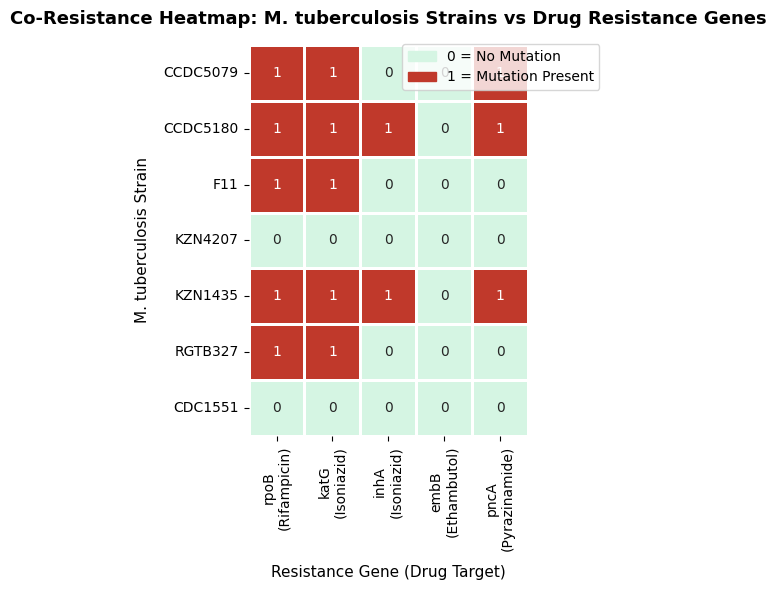

Heatmap saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

strains = ["CCDC5079", "CCDC5180", "F11", "KZN4207", "KZN1435", "RGTB327", "CDC1551"]
genes   = ["rpoB", "katG", "inhA", "embB", "pncA"]

# Build presence/absence matrix
matrix = pd.DataFrame(0, index=strains, columns=genes)

if not df.empty:
    for _, row in df.iterrows():
        if row["Strain"] in strains and row["Gene"] in genes:
            matrix.loc[row["Strain"], row["Gene"]] = 1

# Rename columns for display
col_labels = [
    "rpoB\n(Rifampicin)",
    "katG\n(Isoniazid)",
    "inhA\n(Isoniazid)",
    "embB\n(Ethambutol)",
    "pncA\n(Pyrazinamide)"
]

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap=["#d5f5e3", "#c0392b"],
    linewidths=0.8,
    linecolor="white",
    cbar=False,
    square=True,
    ax=ax,
    xticklabels=col_labels,
    yticklabels=strains
)

ax.set_title(
    "Co-Resistance Heatmap: M. tuberculosis Strains vs Drug Resistance Genes",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Resistance Gene (Drug Target)", fontsize=11, labelpad=10)
ax.set_ylabel("M. tuberculosis Strain", fontsize=11, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)

# Legend
green_patch = mpatches.Patch(color="#d5f5e3", label="0 = No Mutation")
red_patch   = mpatches.Patch(color="#c0392b", label="1 = Mutation Present")
ax.legend(handles=[green_patch, red_patch], loc="upper right",
          bbox_to_anchor=(1.28, 1.02), fontsize=10)

plt.tight_layout()
plt.savefig("/content/tb_project/results/coresistance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved.")

In [ ]:
strains = ["CCDC5079", "CCDC5180", "F11", "KZN4207", "KZN1435", "RGTB327", "CDC1551"]

print("=" * 58)
print("   pncA UNEXPLAINED RESISTANCE ANALYSIS")
print("=" * 58)

for strain in strains:
    s = df[df["Strain"] == strain] if not df.empty else pd.DataFrame()

    has_rpoB = not s[s["Gene"] == "rpoB"].empty
    has_katG = not s[s["Gene"] == "katG"].empty
    has_inhA = not s[s["Gene"] == "inhA"].empty
    has_embB = not s[s["Gene"] == "embB"].empty
    has_pncA = not s[s["Gene"] == "pncA"].empty

    is_mdr = has_rpoB and has_katG

    if is_mdr and not has_pncA:
        print(f"\n  [FLAG] {strain}")
        print(f"         MDR confirmed — rpoB + katG mutated")
        print(f"         BUT no pncA mutation detected")
        print(f"         → Pyrazinamide resistance is UNEXPLAINED")
    elif is_mdr and has_pncA:
        print(f"\n  [OK]   {strain}")
        print(f"         MDR confirmed + pncA mutated — fully explained")
    else:
        genes_mutated = []
        if has_rpoB: genes_mutated.append("rpoB")
        if has_katG: genes_mutated.append("katG")
        if has_inhA: genes_mutated.append("inhA")
        if has_embB: genes_mutated.append("embB")
        if has_pncA: genes_mutated.append("pncA")
        status = ", ".join(genes_mutated) if genes_mutated else "no target gene mutations"
        print(f"\n  [INFO] {strain}")
        print(f"         Not MDR — mutations found in: {status}")

print("\n" + "=" * 58)

   pncA UNEXPLAINED RESISTANCE ANALYSIS

  [OK]   CCDC5079
         MDR confirmed + pncA mutated — fully explained

  [OK]   CCDC5180
         MDR confirmed + pncA mutated — fully explained

  [FLAG] F11
         MDR confirmed — rpoB + katG mutated
         BUT no pncA mutation detected
         → Pyrazinamide resistance is UNEXPLAINED

  [INFO] KZN4207
         Not MDR — mutations found in: no target gene mutations

  [OK]   KZN1435
         MDR confirmed + pncA mutated — fully explained

  [FLAG] RGTB327
         MDR confirmed — rpoB + katG mutated
         BUT no pncA mutation detected
         → Pyrazinamide resistance is UNEXPLAINED

  [INFO] CDC1551
         Not MDR — mutations found in: no target gene mutations



In [ ]:
strains = ["CCDC5079", "CCDC5180", "F11", "KZN4207", "KZN1435", "RGTB327", "CDC1551"]

print("=" * 58)
print("   FINAL SUMMARY REPORT")
print("=" * 58)

if not df.empty:
    # Save CSV
    df.to_csv("/content/tb_project/results/mutation_table.csv", index=False)
    print(f"\nTotal mutations detected across all strains: {len(df)}")
    print(f"Strains analyzed: {len(strains)}")
    print(f"Resistance genes screened: rpoB, katG, inhA, embB, pncA\n")

    # Per gene summary — unique strains
    print("Mutation frequency per gene:")
    print("-" * 45)
    summary = df.groupby(["Gene","Drug"])["Strain"].nunique().reset_index()
    summary.columns = ["Gene", "Drug", "Strains_Affected"]
    total = len(strains)
    summary["Frequency"] = summary["Strains_Affected"].astype(str) + f"/{total} strains"
    summary = summary.sort_values("Strains_Affected", ascending=False)
    print(summary[["Gene","Drug","Frequency"]].to_string(index=False))

    # Per strain summary
    print("\nMutations per strain:")
    print("-" * 45)
    per_strain = df.groupby("Strain")["Gene"].apply(
        lambda x: ", ".join(sorted(x.unique()))
    ).reset_index()
    per_strain.columns = ["Strain", "Genes_Mutated"]
    per_strain["Count"] = df.groupby("Strain")["Gene"].nunique().values
    print(per_strain.to_string(index=False))

print("\nFiles saved:")
print("  /content/tb_project/results/mutation_table.csv")
print("  /content/tb_project/results/coresistance_heatmap.png")

   FINAL SUMMARY REPORT

Total mutations detected across all strains: 20
Strains analyzed: 7
Resistance genes screened: rpoB, katG, inhA, embB, pncA

Mutation frequency per gene:
---------------------------------------------
Gene         Drug   Frequency
katG    Isoniazid 5/7 strains
rpoB   Rifampicin 5/7 strains
pncA Pyrazinamide 3/7 strains
inhA    Isoniazid 2/7 strains

Mutations per strain:
---------------------------------------------
  Strain          Genes_Mutated  Count
CCDC5079       katG, pncA, rpoB      3
CCDC5180 inhA, katG, pncA, rpoB      4
     F11             katG, rpoB      2
 KZN1435 inhA, katG, pncA, rpoB      4
 RGTB327             katG, rpoB      2

Files saved:
  /content/tb_project/results/mutation_table.csv
  /content/tb_project/results/coresistance_heatmap.png
